In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mandy3883/sample-paysim/sample_paysim.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mandy3883/sample-paysim/sample_paysim.csv")

print(df.shape)
df.head()

(200000, 13)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,sender_balance_diff,receiver_balance_diff
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0,-330218.42,-330218.42
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0,11647.08,0.00
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0,-152264.21,-152264.21
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0,0.00,1551760.63
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0,-78172.30,-78172.30


In [4]:
print(df["isFraud"].value_counts())

print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    199732
1       268
Name: count, dtype: int64
isFraud
0    99.866
1     0.134
Name: proportion, dtype: float64


In [5]:
df["amount_log"] = np.log1p(df["amount"])

In [6]:
df["sender_balance_diff"] = (df["oldbalanceOrg"]- df["newbalanceOrig"])

In [7]:
df["receiver_balance_diff"] = (df["newbalanceDest"]- df["oldbalanceDest"])

In [8]:
df["sender_error"] = ( df["oldbalanceOrg"]- df["amount"]- df["newbalanceOrig"])

In [9]:
df["receiver_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

In [10]:
df["amount_to_balance"] = ( df["amount"]/(df["oldbalanceOrg"] + 1))

In [11]:
df["origin_zero"] = (df["oldbalanceOrg"] == 0).astype(int)

df["dest_zero"] = (df["oldbalanceDest"] == 0).astype(int)

In [12]:
df.drop(
    columns=[
        "nameOrig",
        "nameDest"
    ],
    inplace=True
)

In [13]:
df = pd.get_dummies(df,columns=["type"])

In [14]:
X = df.drop( columns=["isFraud"])

y = df["isFraud"]

In [15]:
remove_cols = [
    "sender_error",
    "receiver_error",
    "newbalanceOrig",
    "newbalanceDest",
    "isFlaggedFraud"
]

X_v3 = X.drop(
    columns=remove_cols
)

In [16]:
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
scale_pos_weight = (
    len(y_train_v3[y_train_v3 == 0])
    /
    len(y_train_v3[y_train_v3 == 1])
)

print(scale_pos_weight)

746.6635514018692


In [18]:
model_v3 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_v3.fit(
    X_train_v3,
    y_train_v3
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
y_pred_v3 = model_v3.predict(
    X_test_v3
)

y_prob_v3 = model_v3.predict_proba(
    X_test_v3
)[:,1]

In [20]:
print(
    "ROC AUC:",
    roc_auc_score(
        y_test_v3,
        y_prob_v3
    )
)

print(
    "Precision:",
    precision_score(
        y_test_v3,
        y_pred_v3
    )
)

print(
    "Recall:",
    recall_score(
        y_test_v3,
        y_pred_v3
    )
)

print(
    "F1:",
    f1_score(
        y_test_v3,
        y_pred_v3
    )
)

ROC AUC: 0.9999350975669006
Precision: 0.8
Recall: 0.9629629629629629
F1: 0.8739495798319328


In [21]:
print(
    classification_report(
        y_test_v3,
        y_pred_v3
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39946
           1       0.80      0.96      0.87        54

    accuracy                           1.00     40000
   macro avg       0.90      0.98      0.94     40000
weighted avg       1.00      1.00      1.00     40000



In [22]:
cm = confusion_matrix(
    y_test_v3,
    y_pred_v3
)

print(cm)

[[39933    13]
 [    2    52]]


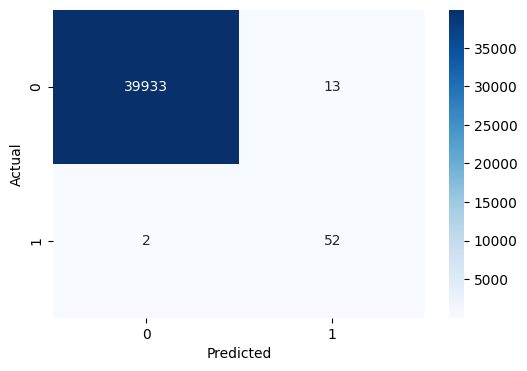

In [23]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
importance_df = pd.DataFrame({
    "feature": X_v3.columns,
    "importance": model_v3.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
4,sender_balance_diff,0.631697
7,amount_to_balance,0.144054
14,type_TRANSFER,0.124918
5,receiver_balance_diff,0.045597
11,type_CASH_OUT,0.025890
0,step,0.009352
2,oldbalanceOrg,0.009057
9,dest_zero,0.005370
13,type_PAYMENT,0.001446
1,amount,0.001027


In [25]:
joblib.dump(
    model_v3,
    "xgboost_v3.pkl"
)

['xgboost_v3.pkl']

In [26]:
joblib.dump(
    list(X_v3.columns),
    "feature_names_v3.pkl"
)

['feature_names_v3.pkl']

In [27]:
print(list(X_v3.columns))

['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'sender_balance_diff', 'receiver_balance_diff', 'amount_log', 'amount_to_balance', 'origin_zero', 'dest_zero', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
